# Chapter 73 — Error and Residuals

> **Prerequisites:** ch072 (Fitting Simple Models)
>
> **You will learn:**
> - Define and compute residuals, RMSE, MAE, R²
> - Diagnose model problems from residual plots
> - Understand bias-variance tradeoff at an intuitive level
> - Use residuals to improve model selection
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

**Residuals** are the differences between observed and predicted values:
eᵢ = yᵢ - ŷᵢ = yᵢ - f(xᵢ; θ)

They quantify how wrong the model is, point by point.

**Error metrics:**
- **MSE**: mean((y - ŷ)²) — penalizes large errors more; sensitive to outliers
- **RMSE**: √MSE — same units as y; interpretable as "typical error size"
- **MAE**: mean(|y - ŷ|) — less sensitive to outliers
- **R²**: 1 - SS_res/SS_tot — fraction of variance explained; 1=perfect, 0=mean prediction

**Residual diagnostics:**
- **Random scatter**: good fit. Residuals should look like noise.
- **Systematic pattern** (curve, wave): wrong model structure
- **Heteroscedasticity** (increasing spread): variance isn't constant — may need log transform
- **Outliers**: large individual residuals — check data quality

---

## 2. Intuition & Mental Models

**Physical analogy:** Error diagnostics are like checking the alignment of a car. The car may drive straight on average (low mean error) but drift left under braking (systematic residual pattern at high speed). The pattern reveals a structural problem.

**Computational analogy:** In ML training, the loss curve is a macro-level error metric. The residuals are the micro-level: each data point's individual misfit. Training minimizes the loss, but residual analysis checks if the model structure is correct.

---

## 3. Visualization

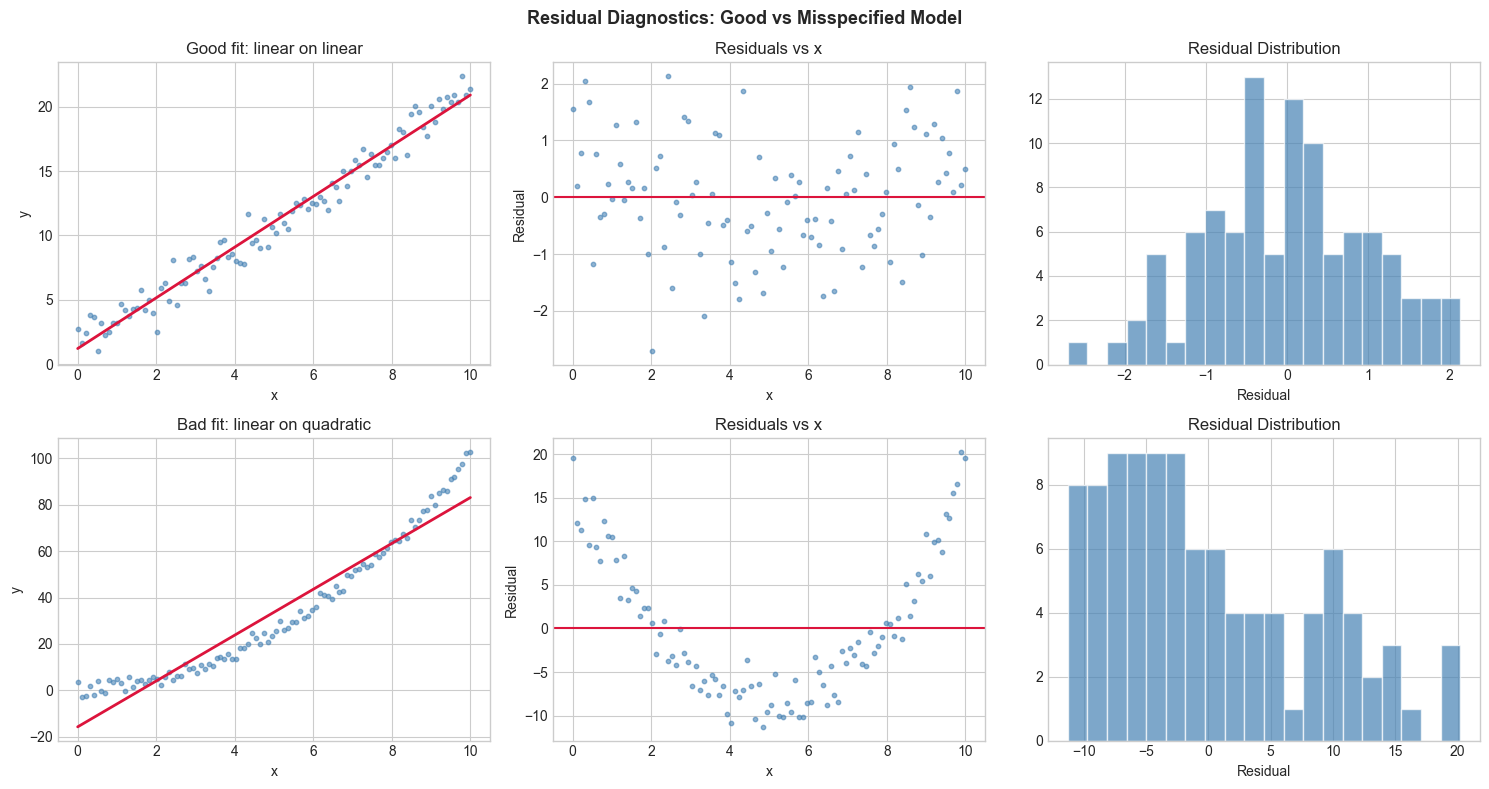

In [1]:
# --- Visualization: Residual diagnostic plots ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(0)
x = np.linspace(0, 10, 100)

# Case 1: Correct model (linear)
y_true = 2*x + 1
y_obs = y_true + np.random.normal(0, 1, 100)
m, b, _ = (lambda c: (c[0],c[1], None))(np.linalg.lstsq(np.column_stack([x,np.ones(100)]), y_obs, rcond=None)[0])
y_hat_good = m*x + b
res_good = y_obs - y_hat_good

# Case 2: Wrong model (quadratic data, linear fit)
y_quad = x**2 + np.random.normal(0, 2, 100)
m2, b2 = np.linalg.lstsq(np.column_stack([x,np.ones(100)]), y_quad, rcond=None)[0]
y_hat_bad = m2*x + b2
res_bad = y_quad - y_hat_bad

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, (y_obs_plot, y_hat, res, label) in enumerate([(y_obs, y_hat_good, res_good, 'Good fit: linear on linear'),
                                                        (y_quad, y_hat_bad, res_bad, 'Bad fit: linear on quadratic')]):
    axes[row,0].scatter(x, y_obs_plot, s=10, color='steelblue', alpha=0.6)
    axes[row,0].plot(x, y_hat, color='crimson', linewidth=2)
    axes[row,0].set_title(label); axes[row,0].set_xlabel('x'); axes[row,0].set_ylabel('y')
    
    axes[row,1].scatter(x, res, s=10, color='steelblue', alpha=0.6)
    axes[row,1].axhline(0, color='crimson', linewidth=1.5)
    axes[row,1].set_title('Residuals vs x'); axes[row,1].set_xlabel('x'); axes[row,1].set_ylabel('Residual')
    
    axes[row,2].hist(res, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    axes[row,2].set_title('Residual Distribution'); axes[row,2].set_xlabel('Residual')

plt.suptitle('Residual Diagnostics: Good vs Misspecified Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Python Implementation

In [2]:
# --- Implementation: Error metrics and residual analysis ---
import numpy as np

def compute_metrics(y_true, y_pred):
    """
    Compute standard regression error metrics.
    
    Args:
        y_true, y_pred: np.ndarray of observed and predicted values
    Returns:
        dict of metric name -> value
    """
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    residuals = y_true - y_pred
    n = len(y_true)
    
    mse = np.mean(residuals**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(residuals))
    
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2,
            'n': n, 'residual_mean': residuals.mean(), 'residual_std': residuals.std()}

def residual_autocorrelation(residuals, lag=1):
    """Compute lag-k autocorrelation of residuals.
    If non-zero: systematic temporal pattern in errors."""
    r = residuals - residuals.mean()
    return np.sum(r[lag:] * r[:-lag]) / np.sum(r**2)

# Demo
np.random.seed(1)
x = np.linspace(0, 10, 80)
y = 3*x + 2 + np.random.normal(0, 2, 80)
m, b = np.linalg.lstsq(np.column_stack([x, np.ones(80)]), y, rcond=None)[0]
y_hat = m*x + b

metrics = compute_metrics(y, y_hat)
print("Error metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

print(f"\nResidual autocorrelation (lag 1): {residual_autocorrelation(y - y_hat):.4f}")
print("(Near 0 = good; large value = systematic pattern in errors)")

Error metrics:
  mse: 3.5895
  rmse: 1.8946
  mae: 1.5188
  r2: 0.9578
  n: 80.0000
  residual_mean: 0.0000
  residual_std: 1.8946

Residual autocorrelation (lag 1): -0.0744
(Near 0 = good; large value = systematic pattern in errors)


---

## 6. Experiments

**Experiment 1:** Generate data with heteroscedastic errors (variance grows with x): y = 2x + noise where noise ~ N(0, x). Plot residuals vs x. What pattern do you see?

**Experiment 2:** For the same dataset, try a log transformation (fit to log(y) vs x). Do the residuals become more homoscedastic?

---

## 7. Exercises

**Easy 1.** Compute MSE, RMSE, MAE, R² for predictions [2, 4, 6] vs true [2.1, 3.8, 6.5].

**Easy 2.** If R² = 0.9, what fraction of variance is unexplained? What does R² = 0 mean?

**Medium 1.** Implement a `residual_plot_suite(y_true, y_pred, x)` that generates: (1) residuals vs x, (2) residuals vs y_pred, (3) histogram of residuals, (4) Q-Q plot against normal.

**Medium 2.** Generate data from y = sin(x) + noise on [0, 10]. Fit with linear, cubic, and sine+linear models. Compare R² and residual autocorrelation. Which model has least residual structure?

**Hard.** Prove that R² can be negative when the model is worse than predicting the mean. Construct a concrete example where a quadratic model gives R² < 0 on test data (despite good training R²). This demonstrates overfitting.

---

## 9. Chapter Summary & Connections

- Residual = observed - predicted; should look like random noise for a good fit
- RMSE: typical error size in original units; R²: fraction of variance explained
- Residual patterns reveal model misspecification (curve → wrong family, increasing spread → heteroscedasticity)
- Residual autocorrelation detects systematic temporal patterns

**Forward connections:**
- ch277 (Bias and Variance) formalizes the decomposition of prediction error
- ch288 (Overfitting) connects residual patterns to generalization failure
- ch290 (Cross Validation) uses held-out residuals to estimate generalization error